### **install**

In [ ]:
# !pip install numpy matplotlib opencv-python

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

### **numpy**

create an array

In [4]:
array_2d = np.array([[10, 20, 30],
                     [40, 50, 60]])
print(array_2d)


[[10 20 30]
 [40 50 60]]


In [7]:
print("-" * 100)
print(f"Shape (شکل): {array_2d.shape}")
print(f"Size (تعداد کل المان‌ها): {array_2d.size}")
print(f"Dtype (نوع داده): {array_2d.dtype}")
print("-" * 100)

----------------------------------------------------------------------------------------------------
Shape (شکل): (2, 3)
Size (تعداد کل المان‌ها): 6
Dtype (نوع داده): int32
----------------------------------------------------------------------------------------------------


Create Common Arrays

In [8]:
zeros_array = np.zeros((3, 4), dtype=np.uint8) # np.uint8 برای تصاویر بسیار رایج است
ones_array = np.ones((2, 2)) * 255 # آرایه‌ای از 255 (معمولاً سفید)

Slicing

In [9]:
slice_example = array_2d[0, 0:3] 
print("--- اسلایس کردن (Slicing) ---")
print(f"سطر اول: {slice_example}")
# انتخاب عنصر در سطر دوم و ستون سوم
print(f"عنصر (1, 2): {array_2d[1, 2]}") 
print("-" * 20)

--- اسلایس کردن (Slicing) ---
سطر اول: [10 20 30]
عنصر (1, 2): 60
--------------------


### **Matplotlib**

In [10]:
dummy_image = np.random.randint(0, 256, size=(10, 10), dtype=np.uint8)

In [11]:
print(dummy_image)

[[ 15 193  34  87  84  39 203 186  67 113]
 [ 83 120 153 168 230 188  78 169 130 200]
 [168 178  95 218 190 108 101 201 235  57]
 [198  23  19 106  35 204  59  41 147 172]
 [124  22  80  39 213 168 165  78  41 148]
 [234  10 246  93 191 248   2 181 245 115]
 [ 60 246 248 214 255 216  19  75 228 160]
 [ 55 149 125  44 138 130 104 164 169 155]
 [ 40  78  42 176 236  10 206   6 247 181]
 [ 81  29  73 255 253  75 229 148 113  45]]


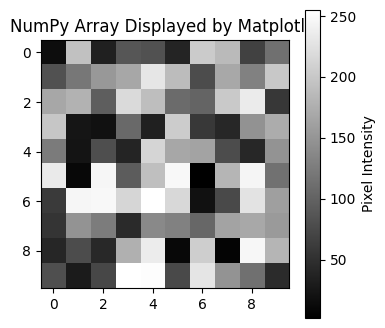

In [13]:
plt.figure(figsize=(4, 4))
plt.imshow(dummy_image, cmap='gray') 
plt.title("NumPy Array Displayed by Matplotlib")
plt.colorbar(label='Pixel Intensity')
plt.show()

### **OpenCV**

In [15]:
image_path = r'images/Lenna.png'

In [20]:
img = cv2.imread(image_path)[:,:,0]

In [21]:
img.shape 

(512, 512)

(-0.5, 511.5, 511.5, -0.5)

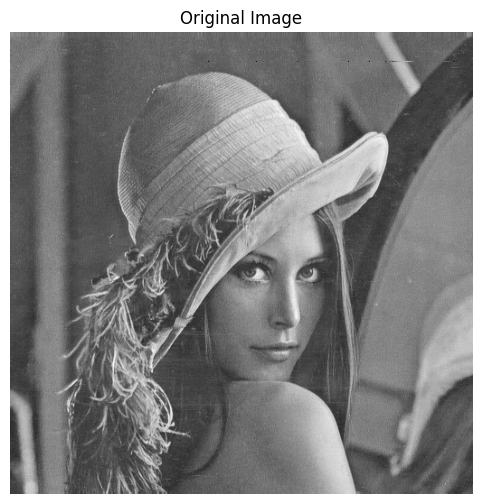

In [36]:
plt.figure(figsize=(15, 6))

plt.imshow(img, cmap='grey')
plt.title("Original Image")
plt.axis('off')

In [28]:
rows, cols = img.shape

In [29]:
# Sobel X-direction kernel (Detects vertical edges)
kernel_sobel_x = np.array([[-1, 0, 1],
                           [-2, 0, 2],
                           [-1, 0, 1]], dtype=np.float32)

# Sobel Y-direction kernel (Detects horizontal edges)
kernel_sobel_y = np.array([[-1, -2, -1],
                           [0, 0, 0],
                           [1, 2, 1]], dtype=np.float32)

In [27]:
gradient_x = np.zeros_like(img, dtype=np.float32)
gradient_y = np.zeros_like(img, dtype=np.float32)

In [31]:
for r in range(1, rows - 1): 
    for c in range(1, cols - 1):
        
        # Extract the 3x3 patch (neighborhood) centered at (r, c)
        image_patch = img[r-1:r+2, c-1:c+2]
        
        # Convolution operation (Dot product for the patch and the kernel)
        # Gx = patch * Kernel_X (element-wise multiplication, then sum)
        gradient_x[r, c] = np.sum(image_patch * kernel_sobel_x)
        
        # Gy = patch * Kernel_Y (element-wise multiplication, then sum)
        gradient_y[r, c] = np.sum(image_patch * kernel_sobel_y)

In [32]:
gradient_magnitude = np.sqrt(gradient_x**2 + gradient_y**2)

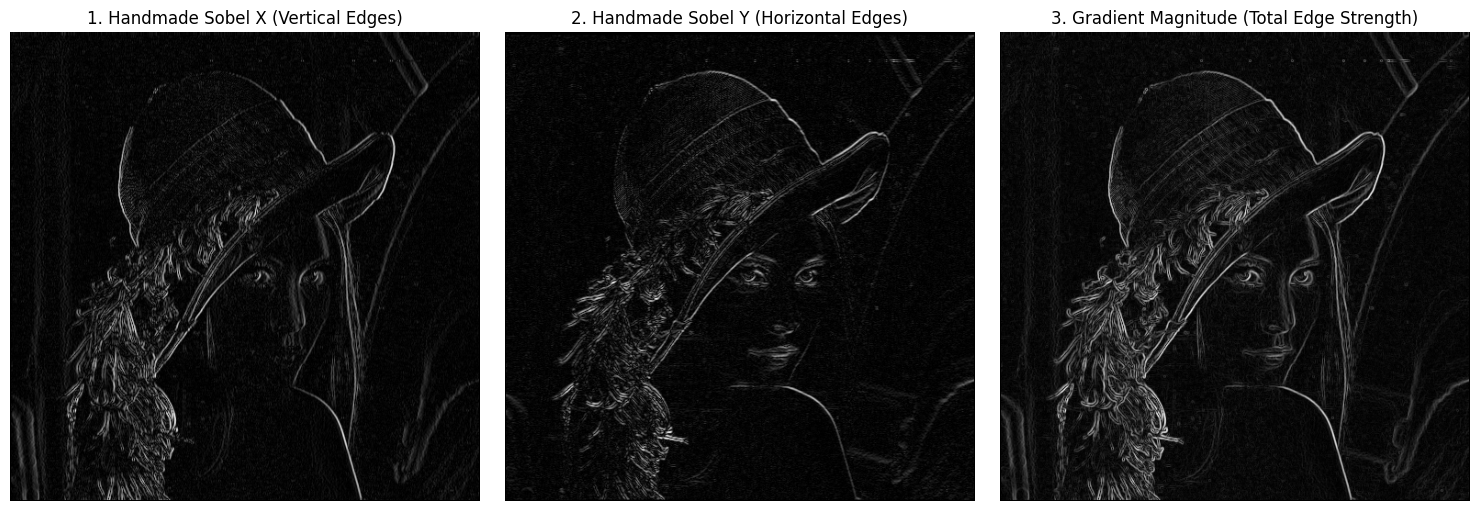


**Code Execution Complete.**


In [35]:
# --- 4. Normalization and Display ---

plt.figure(figsize=(15, 5))

# --- Sobel X Result ---
# Take absolute value to show all changes (positive and negative gradients)
sobel_x_abs = np.abs(gradient_x)
# Normalize to 0-255 range and convert to uint8 for display
max_val_x = np.max(sobel_x_abs)
sobel_x_display = np.uint8(255 * sobel_x_abs / max_val_x) if max_val_x > 0 else np.zeros_like(sobel_x_abs, dtype=np.uint8)

plt.subplot(1, 3, 1)
plt.imshow(sobel_x_display, cmap='gray')
plt.title("1. Handmade Sobel X (Vertical Edges)")
plt.axis('off')

# --- Sobel Y Result ---
sobel_y_abs = np.abs(gradient_y)
max_val_y = np.max(sobel_y_abs)
sobel_y_display = np.uint8(255 * sobel_y_abs / max_val_y) if max_val_y > 0 else np.zeros_like(sobel_y_abs, dtype=np.uint8)

plt.subplot(1, 3, 2)
plt.imshow(sobel_y_display, cmap='gray')
plt.title("2. Handmade Sobel Y (Horizontal Edges)")
plt.axis('off')

# --- Combined Magnitude Result ---
max_val_mag = np.max(gradient_magnitude)
gradient_magnitude_display = np.uint8(255 * gradient_magnitude / max_val_mag) if max_val_mag > 0 else np.zeros_like(gradient_magnitude, dtype=np.uint8)

plt.subplot(1, 3, 3)
plt.imshow(gradient_magnitude_display, cmap='gray')
plt.title("3. Gradient Magnitude (Total Edge Strength)")
plt.axis('off')

plt.tight_layout()
plt.show()

print("\n**Code Execution Complete.**")